In [ ]:
# Importar bibliotecas necessárias
import pandas as pd
import nltk
import math
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from nrclex import NRCLex
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
from sklearn.metrics import f1_score, classification_report

# Obtendo dados 



In [40]:
# URL do conjunto de dados
url = "https://github.com/adashofdata/taylor_swift_data/blob/main/Taylor_Swift_Genius/taylor_swift_genius_data.csv"

# Carregar o arquivo CSV para um DataFrame do pandas
# O parâmetro 'raw=true' é importante para acessar o conteúdo bruto do arquivo no GitHub
df = pd.read_csv(url.replace("blob", "raw"))

# Exibir as primeiras linhas do DataFrame para verificar se os dados foram carregados corretamente
print(df.head())

   index         Album                  Song Name  \
0      0  Taylor Swift  Mary's Song (Oh My My My)   
1      1  Taylor Swift     A Perfectly Good Heart   
2      2  Taylor Swift                 Tim McGraw   
3      3  Taylor Swift     Teardrops On My Guitar   
4      4  Taylor Swift                Cold as You   

                                              Lyrics  
0  She said I was seven and you were nine I looke...  
1  Why would you wanna break A perfectly good hea...  
2  He said the way my blue eyes shined Put those ...  
3  Drew looks at me I fake a smile so he won't se...  
4  You have a way of coming easily to me And when...  


In [41]:
#vendo as colunas
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   index      147 non-null    int64 
 1   Album      147 non-null    object
 2   Song Name  147 non-null    object
 3   Lyrics     147 non-null    object
dtypes: int64(1), object(3)
memory usage: 4.7+ KB
None


In [42]:
# Contar o número de observações para cada categoria da coluna 'Album'
album_counts = df['Album'].value_counts()

# Exibir os resultados
print("Número de observações por Álbum:")
print(album_counts)

Número de observações por Álbum:
Album
Lover           18
Red             16
folklore        16
Reputation      15
evermore        15
Taylor Swift    14
Speak Now       14
Fearless        13
1989            13
Midnights       13
Name: count, dtype: int64


todos os álbuns são a primeira versão \\

> Adicionar aspas


Ou seja: stolen versions, sem deluxe e sem 3am.
![Minha Imagem](https://down-br.img.susercontent.com/file/br-11134207-7qukw-lirubijrmfzzdb)

In [43]:
sorted_song_names = df['Song Name'].sample(n=100, replace=False).tolist()
print("100 nomes de músicas sorteados:")
for song in sorted_song_names:
  print(song)

#Ouvir as músicas e classificar manualmente

100 nomes de músicas sorteados:
Last Kiss
The Story Of Us
Breathe
Vigilante Shit
Don't Blame Me
Question...?
The Best Day
Dancing with Our Hands Tied
Mary's Song (Oh My My My)
Soon You'll Get Better
Starlight
Bejeweled
Cold as You
Hey Stephen
Dear John
This Love
Begin Again
Maroon
How You Get The Girl
A Place In This World
This Is Why We Can’t Have Nice Things
Better Than Revenge
You Need To Calm Down
Karma
​no body, no crime
The Lucky One
​betty
Tell Me Why
Clean
The Outside
​cardigan
Mean
State of Grace
So It Goes...
Haunted
Mine
​ivy
​coney island
Style
Long Live
Cruel Summer
Daylight
​champagne problems
Lover
Welcome to New York
​'tis the damn season
​cowboy like me
Speak Now
Back to December
Miss Americana & The Heartbreak Prince
Look What You Made Me Do
...Ready for It?
Blank Space
​tolerate it
Innocent
22
​my tears ricochet
Tied Together with a Smile
Afterglow
Death by a Thousand Cuts
I Forgot That You Existed
Stay Beautiful
​this is me trying
New Year's Day
Never Grow Up
Shake 

In [44]:
# 1. Carregar a base de músicas classificadas (com separador ;)
musicas_classificadas = pd.read_csv('musicas_classificadas.csv', sep=';')
print("Colunas do df:")
print(df.columns)

print("\nColunas de musicas_classificadas:")
print(musicas_classificadas.columns)


Colunas do df:
Index(['index', 'Album', 'Song Name', 'Lyrics'], dtype='object')

Colunas de musicas_classificadas:
Index(['Música', 'Sentimento'], dtype='object')


In [45]:

# 2. Renomear a coluna "Música" para "Song.Name"
musicas_classificadas = musicas_classificadas.rename(columns={'Música': 'Song Name'})

# 3. Fazer o merge (left_join)
dados = pd.merge(df, musicas_classificadas, on='Song Name', how='left')

# 4. Separar treino (com Sentimento) e teste (sem Sentimento)
treino = dados[dados['Sentimento'].notna()]
teste = dados[dados['Sentimento'].isna()]

# Análise exploratória
Vendo sobre a distribuição dos sentimentos das musicas depois da classificação


C:\Users\user\AppData\Local\Temp\ipykernel_27696\868299744.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


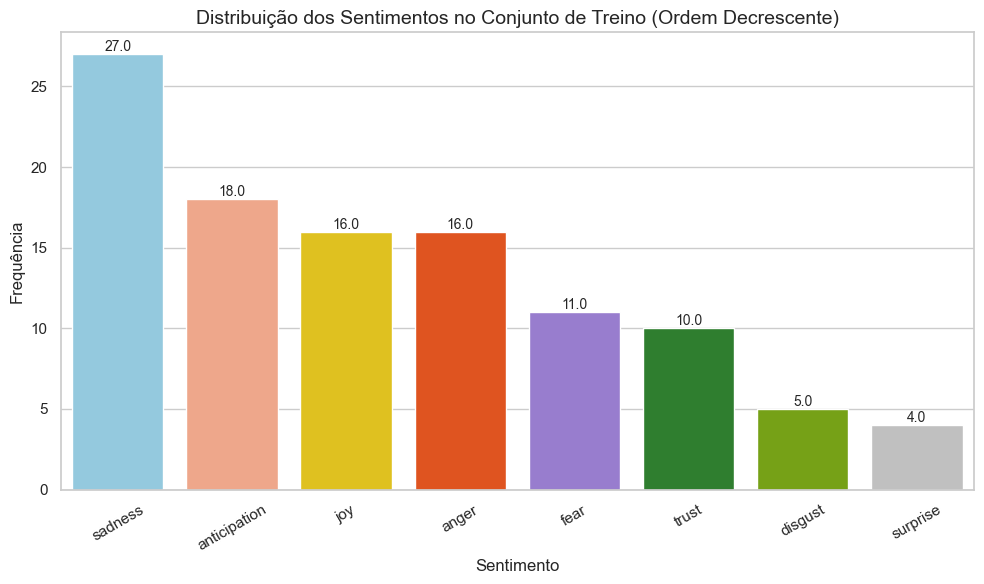

In [46]:
# Define a paleta personalizada com base nos divertidamente
cores_personalizadas = {
    'joy': '#FFD700',         # amarelo alegria
    'sadness': '#87CEEB',     # azul tristeza
    'disgust': '#7FB800',     # verde  "nojinho"
    'anger': '#FF4500',       # vermelho raiva
    'fear': '#9370DB',        # roxo medo
    'trust': '#228B22',       
    'surprise': '#C0C0C0',    
    'anticipation': '#FFA07A'
}

# 1. Frequência dos sentimentos em ordem decrescente
frequencias = treino['Sentimento'].value_counts().sort_values(ascending=False)

# 2. Define a ordem com base nessa frequência
ordem_decrescente = frequencias.index.tolist()

# 3. Cores ordenadas conforme os sentimentos presentes
cores_ordenadas = {k: cores_personalizadas[k] for k in ordem_decrescente if k in cores_personalizadas}

# 4. Plot do gráfico
plt.figure(figsize=(10, 6))
sns.set(style='whitegrid')

ax = sns.countplot(
    data=treino,
    x='Sentimento',
    order=ordem_decrescente,
    palette=cores_ordenadas
)

# 5. Rótulos em cima das barras
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f'{altura}', 
                (p.get_x() + p.get_width() / 2, altura),
                ha='center', va='bottom', fontsize=10)

# 6. Ajustes finais
plt.title('Distribuição dos Sentimentos no Conjunto de Treino (Ordem Decrescente)', fontsize=14)
plt.xlabel('Sentimento')
plt.ylabel('Frequência')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_27696\3933405882.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


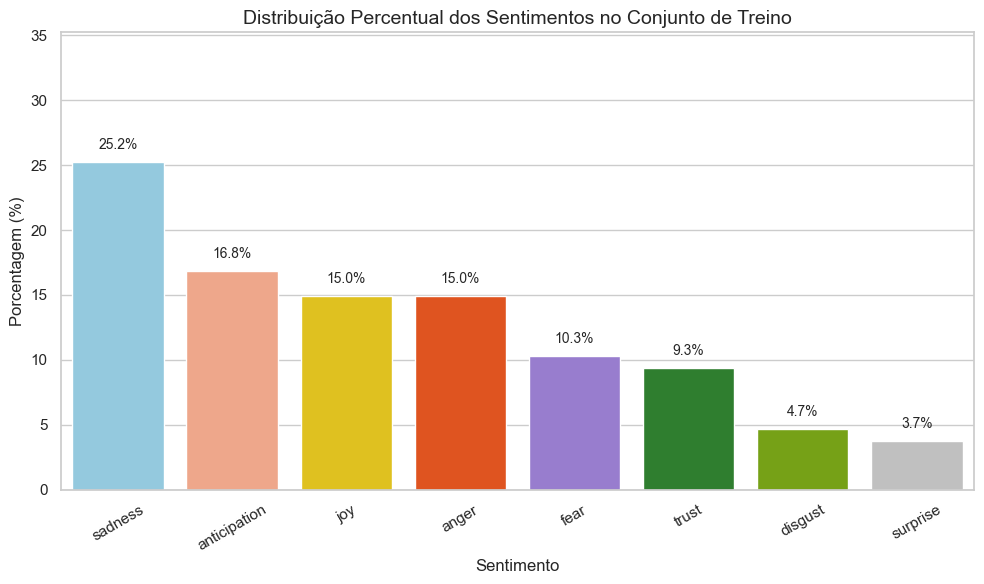

In [47]:
# Frequência percentual em ordem decrescente
frequencias = (
    treino['Sentimento']
    .value_counts(normalize=True)
    .sort_values(ascending=False) * 100
)

# Cores reordenadas de acordo com a frequência
cores_ordenadas = {k: cores_personalizadas[k] for k in frequencias.index if k in cores_personalizadas}

# Plot
plt.figure(figsize=(10, 6))
sns.set(style='whitegrid')
sns.barplot(
    x=frequencias.index,
    y=frequencias.values,
    palette=cores_ordenadas
)

# Adiciona os valores no topo das barras
for i, v in enumerate(frequencias.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=10)

plt.title('Distribuição Percentual dos Sentimentos no Conjunto de Treino', fontsize=14)
plt.xlabel('Sentimento')
plt.ylabel('Porcentagem (%)')
plt.ylim(0, frequencias.max() + 10)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Pré-processamento

O artigo de referência fez como pré-processamento linguístico a **normalização** dos textos antes da anotação para tratar as postagens antes de alimentar os modelos de aprendizado de máquina

In [ ]:
#vou fazer essa normalização no treino e no teste (eu deveria ter feito antes)
import nltk

# Baixar os recursos necessários
nltk.download('punkt_tab')        # Para tokenização
nltk.download('stopwords')        # Para stop words
nltk.download('wordnet')          # Para lematização
nltk.download('omw-1.4')          # Multilingual wordnet (recomendado)

# Agora você pode usar sua função normalmente
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...


In [80]:

#fiz uma função com tudo o q o prof faz no slide
def normalizar_texto(text):
    # 1. Converter para Minúsculas
    text_lower = text.lower()

    # 2. Tokenização (para inglês)
    tokens = nltk.word_tokenize(text_lower, language='english')

    # 3. Remover Pontuação e Números
    # Filtra palavras que contêm apenas caracteres alfabéticos (a-z)
    tokens_no_punct_num = [word for word in tokens if word.isalpha()]

    # 4. Remover Stop Words (para inglês)
    stop_words_en = set(stopwords.words('english'))
    tokens_no_stopwords = [word for word in tokens_no_punct_num if word not in stop_words_en]

    # 5. Lematização
    # Inicializa o lematizador
    lemmatizer = WordNetLemmatizer()
    tokens_lemmatized = [lemmatizer.lemmatize(word) for word in tokens_no_stopwords]

    return tokens_lemmatized

tokens = dados['Lyrics'].apply(normalizar_texto)
print(tokens)

#voltar com o tokens pro df e dividir dnv em treino e teste 
dados['tokens'] = tokens
# 4. Separar treino (com Sentimento) e teste (sem Sentimento)
treino = dados[dados['Sentimento'].notna()]
teste = dados[dados['Sentimento'].isna()]

0      [said, seven, nine, looked, like, star, shined...
1      [would, wan, na, break, perfectly, good, heart...
2      [said, way, blue, eye, shined, put, georgia, s...
3      [drew, look, fake, smile, wo, see, want, needi...
4      [way, coming, easily, take, take, best, start,...
                             ...                        
142    [remember, good, girl, sad, boy, big, city, wr...
143    [baby, love, think, little, kind, notice, walk...
144    [one, night, moon, ago, saw, fleck, could, lig...
145    [rain, wanted, comfortable, wanted, pain, want...
146    [upon, time, planet, fate, star, aligned, ende...
Name: Lyrics, Length: 147, dtype: object


### Frequência de palavras

In [94]:
print(treino.head())

   index         Album                  Song Name  \
0      0  Taylor Swift  Mary's Song (Oh My My My)   
1      1  Taylor Swift     A Perfectly Good Heart   
2      2  Taylor Swift                 Tim McGraw   
3      3  Taylor Swift     Teardrops On My Guitar   
4      4  Taylor Swift                Cold as You   

                                              Lyrics Sentimento  \
0  She said I was seven and you were nine I looke...        joy   
1  Why would you wanna break A perfectly good hea...    sadness   
2  He said the way my blue eyes shined Put those ...    sadness   
3  Drew looks at me I fake a smile so he won't se...    sadness   
4  You have a way of coming easily to me And when...    sadness   

                                              tokens  
0  [said, seven, nine, looked, like, star, shined...  
1  [would, wan, na, break, perfectly, good, heart...  
2  [said, way, blue, eye, shined, put, georgia, s...  
3  [drew, look, fake, smile, wo, see, want, needi...  
4  

In [ ]:
# 2. usa FreqDist sobre a lista de tokens em minúsculo
tokens_flat = [token for sublist in tokens for token in sublist]
freq = nltk.FreqDist(tokens_flat)
# 3. imprime os tokens, os types e e suas frequências
print('vocabulário: ', set(tokens_flat)) # o set elimina repetições da lista
# assim, gera o vocabulário!!!

print('\n tamanho do vocabulario:')
print(len( set(tokens_flat)))
print('\nfrequência de cada type (palavra):')
print(freq.most_common())


vocabulário:  {'parade', 'left', 'home', 'none', 'glimpse', 'ground', 'discovered', 'bet', 'work', 'crown', 'penny', 'guitar', 'six', 'roll', 'lock', 'flying', 'car', 'afterglow', 'cutting', 'grass', 'yes', 'lake', 'vow', 'singing', 'punched', 'pierced', 'swimming', 'waitin', 'paralyzed', 'accent', 'handle', 'cruisin', 'affairyou', 'darker', 'path', 'impossible', 'yesterday', 'peter', 'diamond', 'strange', 'senior', 'opacity', 'shaky', 'trampled', 'starved', 'playboy', 'full', 'linger', 'give', 'almost', 'device', 'hazy', 'separated', 'old', 'ride', 'without', 'incandescent', 'wheel', 'situation', 'rock', 'crazier', 'potion', 'receipt', 'tune', 'bridesmaid', 'hear', 'close', 'magazine', 'fancy', 'passenger', 'quicksand', 'curtain', 'traded', 'unless', 'ago', 'west', 'also', 'curve', 'riviera', 'shit', 'religion', 'desperately', 'addressed', 'space', 'acid', 'best', 'troubling', 'sink', 'byline', 'pause', 'carrying', 'wife', 'whiskey', 'persist', 'travel', 'bunch', 'blue', 'cliffside', 

# Engenharia de atributos


## TF-IDF

Matriz Documento-Termo (Document-TermMatrix –DTM)
A DTM é o formato mais básico para representar um corpusde forma numérica.
É uma matriz numérica, onde:
* Cada **linha** corresponde a um documento *i*.
* Cada **coluna** corresponde a um termo *j* (i.e., um token específico).
* Cada **célula** vai registrar o **peso (numérico)** do termo *j* no documento *i*.
    * A ideia é que o peso seja capaz de representar a **importância** do termo *j* para **caracterizar** o documento *i*.

In [84]:
dados['tokens_string'] = dados['tokens'].apply(lambda x: ' '.join(x))
tf_vect = TfidfVectorizer()
dtm = tf_vect.fit_transform(dados['tokens_string']).toarray()
print('\ndtm:')
print(dtm)
print("\nTF-IDF Shape:", dtm.shape)


dtm:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]

TF-IDF Shape: (147, 2844)


In [ ]:
# - 147 documentos (músicas)
# - 2844 palavras únicas no vocabulário
print(f"\nESTATÍSTICAS POR MÚSICA:")
words_per_song = np.sum(dtm > 0, axis=1)  # palavras diferentes por música
print(f"Palavras diferentes por música - Média: {np.mean(words_per_song):.1f}")
print(f"Palavras diferentes por música - Min: {np.min(words_per_song)}")
print(f"Palavras diferentes por música - Max: {np.max(words_per_song)}")




ESTATÍSTICAS POR MÚSICA:
Palavras diferentes por música - Média: 80.2
Palavras diferentes por música - Min: 41
Palavras diferentes por música - Max: 134


In [ ]:
print(f"\nPALAVRAS MAIS IMPORTANTES GLOBALMENTE:")
# Soma TF-IDF de cada palavra em todas as músicas
word_importance = np.sum(dtm, axis=0)
# Ordena por importância
top_indices = np.argsort(word_importance)[::-1][:20]
feature_names = tf_vect.get_feature_names_out()

for i, idx in enumerate(top_indices):
    word = feature_names[idx]
    importance = word_importance[idx]
    print(f"{i+1:2d}. {word:<15} (TF-IDF total: {importance:.3f})")


PALAVRAS MAIS IMPORTANTES GLOBALMENTE:
 1. know            (TF-IDF total: 7.474)
 2. like            (TF-IDF total: 6.915)
 3. oh              (TF-IDF total: 6.839)
 4. never           (TF-IDF total: 5.967)
 5. love            (TF-IDF total: 5.494)
 6. na              (TF-IDF total: 5.012)
 7. time            (TF-IDF total: 4.718)
 8. go              (TF-IDF total: 4.172)
 9. think           (TF-IDF total: 4.130)
10. one             (TF-IDF total: 4.084)
11. back            (TF-IDF total: 3.861)
12. see             (TF-IDF total: 3.827)
13. want            (TF-IDF total: 3.770)
14. wan             (TF-IDF total: 3.739)
15. baby            (TF-IDF total: 3.706)
16. say             (TF-IDF total: 3.610)
17. could           (TF-IDF total: 3.606)
18. ever            (TF-IDF total: 3.564)
19. get             (TF-IDF total: 3.484)
20. would           (TF-IDF total: 3.474)


In [92]:
albums = dados['Album'].unique()

for album in albums:
    print(f"\nAlbum: {album}")
    album_indices = dados[dados['Album'] == album].index
    album_dtm_subset = dtm[album_indices, :]
    word_importance_album = np.sum(album_dtm_subset, axis=0)

    top_indices_album = np.argsort(word_importance_album)[::-1][:10]
    for i, idx in enumerate(top_indices_album):
        word = feature_names[idx]
        importance = word_importance_album[idx]
        print(f"{i+1:2d}. {word:<15} (TF-IDF total: {importance:.3f})")
    total_words_album = 0
    for idx in album_indices:
        total_words_album += len(str(dados.loc[idx, 'Lyrics']).split())

    print(f"**Total de palavras no álbum:** {total_words_album}")


Album: Taylor Swift
 1. oh              (TF-IDF total: 1.368)
 2. beautiful       (TF-IDF total: 0.925)
 3. na              (TF-IDF total: 0.909)
 4. know            (TF-IDF total: 0.905)
 5. wan             (TF-IDF total: 0.863)
 6. song            (TF-IDF total: 0.728)
 7. never           (TF-IDF total: 0.723)
 8. said            (TF-IDF total: 0.720)
 9. back            (TF-IDF total: 0.714)
10. see             (TF-IDF total: 0.634)
**Total de palavras no álbum:** 4066

Album: Fearless
 1. know            (TF-IDF total: 1.284)
 2. sorry           (TF-IDF total: 0.933)
 3. oh              (TF-IDF total: 0.906)
 4. belong          (TF-IDF total: 0.769)
 5. rain            (TF-IDF total: 0.721)
 6. feel            (TF-IDF total: 0.718)
 7. help            (TF-IDF total: 0.713)
 8. ca              (TF-IDF total: 0.669)
 9. tell            (TF-IDF total: 0.621)
10. never           (TF-IDF total: 0.618)
**Total de palavras no álbum:** 4557

Album: Speak Now
 1. grow            (TF-IDF to

reputation foi o que ela mais hablou

# Modelos de Classificação

Treinar modelos de classificação separados para cada sinal em uma configuração "one-vs-all". 
Para cada sentimento,  criar um modelo que responde:
"Essa música é [sentimento X] ou não?"


## Usando BERT com transformers multi-classe

In [113]:
# Label encoding dos sentimentos
label_encoder = LabelEncoder()
treino['label'] = label_encoder.fit_transform(treino['Sentimento'])

# Treinar/teste split
X_train, X_test, y_train, y_test = train_test_split(
    treino['Lyrics'], treino['label'], 
    test_size=0.2, random_state=42, stratify=treino['label']
)

# Converter para Dataset do Hugging Face
train_dataset = Dataset.from_dict({'text': X_train.tolist(), 'label': y_train.tolist()})
test_dataset = Dataset.from_dict({'text': X_test.tolist(), 'label': y_test.tolist()})

C:\Users\user\AppData\Local\Temp\ipykernel_27696\2367622441.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  treino['label'] = label_encoder.fit_transform(treino['Sentimento'])


In [114]:
MODEL_NAME = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(example):
    return tokenizer(example['text'], truncation=True, padding='max_length', max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(['text'])
test_dataset = test_dataset.remove_columns(['text'])

train_dataset.set_format('torch')
test_dataset.set_format('torch')

Map: 100%|██████████| 22/22 [00:00<00:00, 889.73 examples/s]


In [115]:
num_labels = len(label_encoder.classes_)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [118]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    save_strategy='no',
    logging_dir='./logs',
    logging_steps=10,
)


ImportError: Using the `Trainer` with `PyTorch` requires `accelerate>=0.26.0`: Please run `pip install transformers[torch]` or `pip install 'accelerate>=0.26.0'`

In [120]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())  # deve retornar True se estiver com GPU


2.7.1+cpu
False


## Modelo  do hugging face


https://huggingface.co/hemanthkotaprolu/BERT-finetuned-plutchik-emotions
This model is a fine-tuned version of google-bert/bert-base-cased on the None dataset. It achieves the following results on the evaluation set:

Loss: 1.0432
Accuracy: 0.6450
F1: 0.6411

In [ ]:
# Mapear rótulos 
unique_sentiments = treino['Sentimento'].unique()
label_to_id = {label: i for i, label in enumerate(unique_sentiments)}
id_to_label = {i: label for label, i in label_to_id.items()}
X_train_full, X_test, y_train_full, y_test = train_test_split(
    treino['Lyrics'], treino['Sentimento'], test_size=0.2, random_state=42, stratify=treino['Sentimento']
)

# Definir o modelo e o tokenizer BERT
MODEL_NAME = 'hemanthkotaprolu/BERT-finetuned-plutchik-emotions'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\models--hemanthkotaprolu--BERT-finetuned-plutchik-emotions. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


In [108]:
y_train_ids = [label_to_id[label] for label in y_train_full]
y_test_ids = [label_to_id[label] for label in y_test]
train_encodings = tokenizer(list(X_train_full), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(X_test), truncation=True, padding=True, max_length=128)
train_encodings = tokenizer(list(X_train_full), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(X_test), truncation=True, padding=True, max_length=128)


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
print(model.config.id2label)

#conferindo as categorias q vao ser resposta

{0: 'anger', 1: 'disgust', 2: 'fear', 3: 'joy', 4: 'sadness', 5: 'surprise', 6: 'trust', 7: 'anticipation', 8: 'neutral'}


## Modelos especializados 
No artigo de referencia o MentalBert que era especializado para saúde mental teve o melhor desempenho, por isso procurei modelos especializados para o trabalho 

* **Modelo especializado em Taylor Swift**: Encontrei 2 modelos especializados em Taylor Swift, mas um é para a geração de letras e outro para análise de sentimentos com as categorias "Love and Beauty", "Growing Up", "Home", "Bad/Remorse", "Contemplative" e "Dance". Não vou usar nenhum. [Modelo 1](https://www.promptlayer.com/models/taylor-swift) | 
[Modelo 2](https://www.codecademy.com/resources/blog/taylor-swift-lyrics-machine-learning)

* **Modelo para classificação de emoções pela roda de Puchnik**: NRCLex classify
comments based on the emotions they carry into eight categories of emotions. NRCLex is a
project (https://pypi.org/project/NRCLex, accessed on 15 April 2022) that has received
approval from MIT (https://www.mit.edu/, accessed on 15 April 2022) and predicts
two sentiments (negative and positive) and eight basic categories of emotions (anger,
fear, anticipation, trust, surprise, sadness, joy, and disgust) in a given text. This package,
which is built on the WordNet (https://wordnet.princeton.edu/, accessed on 17 April 2022)
synonyms set from the NLTK library and the affect lexicon of the National Research Council
of Canada (NRC) (http://saifmohammad.com/WebPages/NRC-Emotion-Lexicon.htm,
accessed on 15 April 2022) has over 27,000 terms. [Fonte](https://pmc.ncbi.nlm.nih.gov/articles/PMC9960438/pdf/sensors-23-01748.pdf)

In [ ]:
from nrclex import NRCLex

texto = treino['Lyrics'][0]
emocional = NRCLex(texto)
print(emocional.raw_emotion_scores)


{'positive': 11, 'anticipation': 7, 'joy': 7, 'trust': 6, 'negative': 5, 'sadness': 2, 'anger': 2, 'disgust': 1, 'surprise': 3, 'fear': 1}


o pacote faz um ranking das emoções da musica, vou pegar a emoção mais frequente

In [105]:
def emocao_predominante(texto):
    analise = NRCLex(texto)
    scores = analise.raw_emotion_scores

    # Ordena as emoções por pontuação (do maior para o menor)
    emocoes_ordenadas = sorted(scores.items(), key=lambda x: x[1], reverse=True)

    for emo, _ in emocoes_ordenadas:
        if emo not in ['positive', 'negative']:
            return emo  # Retorna a primeira emoção válida
    return None  # Caso só tenha positive/negative ou nada


treino.loc[:, 'emocao_nrc'] = treino['Lyrics'].apply(emocao_predominante)

treino.head(20)


,index,Album,Song Name,Lyrics,Sentimento,tokens,emocao_nrc
0,0,Taylor Swift,Mary's Song (Oh My My My),She said I was seven and you were nine I looke...,joy,"[said, seven, nine, looked, like, star, shined...",anticipation
1,1,Taylor Swift,A Perfectly Good Heart,Why would you wanna break A perfectly good hea...,sadness,"[would, wan, na, break, perfectly, good, heart...",sadness
2,2,Taylor Swift,Tim McGraw,He said the way my blue eyes shined Put those ...,sadness,"[said, way, blue, eye, shined, put, georgia, s...",anticipation
3,3,Taylor Swift,Teardrops On My Guitar,Drew looks at me I fake a smile so he won't se...,sadness,"[drew, look, fake, smile, wo, see, want, needi...",joy
4,4,Taylor Swift,Cold as You,You have a way of coming easily to me And when...,sadness,"[way, coming, easily, take, take, best, start,...",sadness
5,5,Taylor Swift,The Outside,I didn't know what I would find When I went lo...,anticipation,"[know, would, find, went, looking, reason, kno...",fear
6,6,Taylor Swift,Should've Said No,It's strange to think the songs we used to sin...,disgust,"[strange, think, song, used, sing, smile, flow...",trust
7,7,Taylor Swift,A Place In This World,"I don't know what I want, so don't ask me 'Cau...",anticipation,"[know, want, ask, still, trying, figure, know,...",anticipation
8,8,Taylor Swift,Our Song,I was ridin' shotgun with my hair undone In th...,joy,"[ridin, shotgun, hair, undone, front, seat, ca...",joy
9,9,Taylor Swift,Picture to Burn,"State the obvious, I didn't get my perfect fan...",anger,"[state, obvious, get, perfect, fantasy, realiz...",anger


In [107]:
# Calcula o F1-score
f1 = f1_score(treino['Sentimento'], treino['emocao_nrc'], average='macro')
print(f'F1-score (macro): {f1:.4f}')

F1-score (macro): 0.1936
